# 📘 Notebook 3: GPT Model Implementation
## Building LLMs from Scratch Workshop

**Objective:** Build a complete GPT architecture from scratch, using the attention mechanism from Notebook 2.

**What you'll build:**
1. Token + Positional Embeddings
2. Layer Normalization
3. Feed-Forward Network
4. Transformer Block (Attention + FFN + Residuals)
5. Full GPT Model
6. Text generation function

---


## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import json

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============================================================
# GPT Configuration
# ============================================================
# We define a small GPT model that can train on a laptop
# GPT-2 Small has 124M params; ours will have ~5-10M params

GPT_CONFIG = {
    "vocab_size": 256,         # Will be updated from tokenizer
    "context_length": 64,      # Max sequence length
    "emb_dim": 128,            # Embedding dimension
    "num_heads": 4,            # Attention heads
    "num_layers": 4,           # Transformer blocks
    "drop_rate": 0.1,          # Dropout rate
    "ff_mult": 4,              # Feed-forward multiplier (ff_dim = emb_dim * ff_mult)
}

# For comparison with real GPT models:
GPT_MODELS = {
    "Our Mini-GPT": GPT_CONFIG,
    "GPT-2 Small":  {"vocab_size": 50257, "context_length": 1024, "emb_dim": 768, "num_heads": 12, "num_layers": 12},
    "GPT-2 Medium": {"vocab_size": 50257, "context_length": 1024, "emb_dim": 1024, "num_heads": 16, "num_layers": 24},
    "GPT-2 Large":  {"vocab_size": 50257, "context_length": 1024, "emb_dim": 1280, "num_heads": 20, "num_layers": 36},
}

for name, cfg in GPT_MODELS.items():
    # Rough parameter estimate
    V = cfg["vocab_size"]
    D = cfg["emb_dim"]
    L = cfg["num_layers"]
    C = cfg.get("context_length", 1024)
    params = V*D + C*D + L*(12*D*D + 8*D) + V*D  # Approximate
    print(f"{name:20s}: ~{params/1e6:7.1f}M parameters (D={D}, L={L})")


Device: cpu
Our Mini-GPT        : ~    0.9M parameters (D=128, L=4)
GPT-2 Small         : ~  163.0M parameters (D=768, L=12)
GPT-2 Medium        : ~  406.2M parameters (D=1024, L=24)
GPT-2 Large         : ~  838.1M parameters (D=1280, L=36)


In [ ]:
# ============================================================
# Project Directory Setup
# ============================================================
# This cell ensures all paths point to the correct directories
# regardless of where you run the notebook from.
import os

# If running from notebooks/ folder
if os.path.basename(os.getcwd()) == 'notebooks':
    PROJECT_ROOT = os.path.abspath('..')
else:
    PROJECT_ROOT = os.path.abspath('.')

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR  = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Results dir:  {RESULTS_DIR}")


## 2. Token and Positional Embeddings

The model needs two types of embeddings:
1. **Token Embeddings:** Convert token IDs → dense vectors
2. **Positional Embeddings:** Tell the model about token order

Both are **learned** (not fixed sinusoidal like in the original Transformer paper).
GPT-2 uses learned positional embeddings.


In [2]:
class GPTEmbedding(nn.Module):
    """
    Combined token + positional embedding layer.
    
    Token embedding:      vocab_size → emb_dim
    Positional embedding: context_length → emb_dim
    Output = token_emb + pos_emb + dropout
    """
    
    def __init__(self, config):
        super().__init__()
        self.token_emb = nn.Embedding(config['vocab_size'], config['emb_dim'])
        self.pos_emb = nn.Embedding(config['context_length'], config['emb_dim'])
        self.dropout = nn.Dropout(config['drop_rate'])
    
    def forward(self, token_ids):
        """
        Args:
            token_ids: [batch_size, seq_len] — integer token IDs
        
        Returns:
            embeddings: [batch_size, seq_len, emb_dim]
        """
        batch_size, seq_len = token_ids.shape
        
        # Token embeddings
        tok_emb = self.token_emb(token_ids)  # [B, T, D]
        
        # Positional embeddings
        positions = torch.arange(seq_len, device=token_ids.device)  # [T]
        pos_emb = self.pos_emb(positions)  # [T, D] — broadcasts over batch
        
        # Combine
        x = self.dropout(tok_emb + pos_emb)
        return x

# Test
emb = GPTEmbedding(GPT_CONFIG)
test_ids = torch.randint(0, GPT_CONFIG['vocab_size'], (2, 16))  # [batch=2, seq=16]
emb_out = emb(test_ids)
print(f"Input token IDs: {test_ids.shape}")
print(f"Embedding output: {emb_out.shape}")
print(f"Parameters: token_emb={GPT_CONFIG['vocab_size']*GPT_CONFIG['emb_dim']:,}, "
      f"pos_emb={GPT_CONFIG['context_length']*GPT_CONFIG['emb_dim']:,}")


Input token IDs: torch.Size([2, 16])
Embedding output: torch.Size([2, 16, 128])
Parameters: token_emb=32,768, pos_emb=8,192


## 3. Layer Normalization

Layer Norm normalizes across the feature dimension (not the batch dimension like BatchNorm).
GPT-2 uses **Pre-Norm** — layer norm is applied *before* attention and FFN, not after.

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$


In [3]:
class LayerNorm(nn.Module):
    """
    Layer Normalization (from scratch).
    
    Normalizes the last dimension of the input.
    Uses learnable scale (gamma) and shift (beta) parameters.
    """
    
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(emb_dim))   # Scale
        self.beta = nn.Parameter(torch.zeros(emb_dim))    # Shift
    
    def forward(self, x):
        # Compute mean and variance over last dimension
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        
        # Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        
        # Scale and shift
        return self.gamma * x_norm + self.beta

# Test and compare with PyTorch's built-in
ln_custom = LayerNorm(128)
ln_torch = nn.LayerNorm(128)

test_x = torch.randn(2, 16, 128)
out_custom = ln_custom(test_x)
out_torch = ln_torch(test_x)

print(f"Input:  {test_x.shape}")
print(f"Output: {out_custom.shape}")
print(f"Mean after norm (should be ~0): {out_custom.mean(dim=-1)[0, :3].detach()}")
print(f"Std after norm (should be ~1):  {out_custom.std(dim=-1)[0, :3].detach()}")


Input:  torch.Size([2, 16, 128])
Output: torch.Size([2, 16, 128])
Mean after norm (should be ~0): tensor([1.1176e-08, 1.8626e-09, 3.7253e-09])
Std after norm (should be ~1):  tensor([1.0039, 1.0039, 1.0039])


## 4. Feed-Forward Network (FFN)

Each transformer block has a **position-wise feed-forward network**:

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

GPT-2 uses **GELU** activation (smoother than ReLU). The inner dimension is typically 4× the embedding dimension.


FFN Input:  torch.Size([2, 16, 128])
FFN Output: torch.Size([2, 16, 128])
FFN Parameters: 131,712
Inner dimension: 512


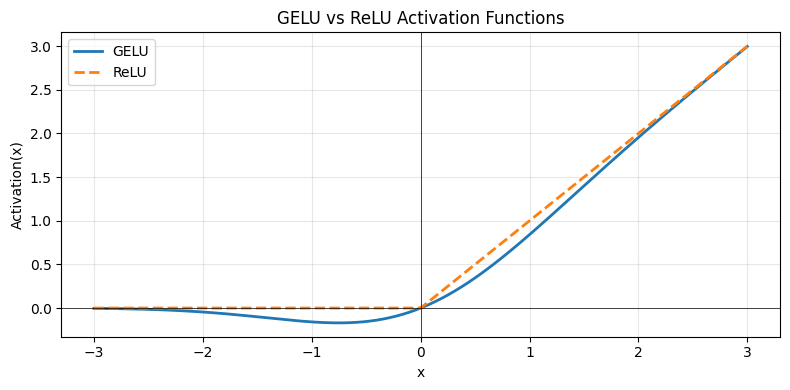

In [11]:
class GELU(nn.Module):
    """
    Gaussian Error Linear Unit activation (from scratch).
    
    GELU(x) = x * Φ(x) where Φ is the cumulative normal distribution.
    Approximation: 0.5 * x * (1 + tanh(sqrt(2/π) * (x + 0.044715 * x³)))
    """
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.
    
    Two linear layers with GELU activation in between.
    Inner dimension = emb_dim * ff_mult (typically 4x).
    """
    
    def __init__(self, config):
        super().__init__()
        emb_dim = config['emb_dim']
        ff_dim = emb_dim * config.get('ff_mult', 4)
        
        self.layers = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            GELU(),
            nn.Linear(ff_dim, emb_dim),
            nn.Dropout(config['drop_rate'])
        )
    
    def forward(self, x):
        return self.layers(x)

# Test
ffn = FeedForward(GPT_CONFIG)
test_x = torch.randn(2, 16, GPT_CONFIG['emb_dim'])
out = ffn(test_x)
print(f"FFN Input:  {test_x.shape}")
print(f"FFN Output: {out.shape}")
print(f"FFN Parameters: {sum(p.numel() for p in ffn.parameters()):,}")
print(f"Inner dimension: {GPT_CONFIG['emb_dim'] * GPT_CONFIG.get('ff_mult', 4)}")

# Visualize GELU vs ReLU
import matplotlib.pyplot as plt
import numpy as np

x_vals = torch.linspace(-3, 3, 200)
gelu_vals = GELU()(x_vals)
relu_vals = F.relu(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals.numpy(), gelu_vals.detach().numpy(), label='GELU', linewidth=2)
plt.plot(x_vals.numpy(), relu_vals.numpy(), label='ReLU', linewidth=2, linestyle='--')
plt.xlabel('x')
plt.ylabel('Activation(x)')
plt.title('GELU vs ReLU Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\gelu_vs_relu.png', dpi=100)
plt.show()


## 5. Multi-Head Causal Attention (from Notebook 2)

We reuse the attention module from Notebook 2:


In [12]:
class CausalMultiHeadAttention(nn.Module):
    """Multi-Head Causal Self-Attention for GPT."""
    
    def __init__(self, config):
        super().__init__()
        emb_dim = config['emb_dim']
        num_heads = config['num_heads']
        context_length = config['context_length']
        drop_rate = config.get('drop_rate', 0.0)
        
        assert emb_dim % num_heads == 0
        
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        
        self.qkv_proj = nn.Linear(emb_dim, 3 * emb_dim, bias=False)
        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=False)
        self.attn_dropout = nn.Dropout(drop_rate)
        self.resid_dropout = nn.Dropout(drop_rate)
        
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
        self.register_buffer('mask', mask.bool())
    
    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)
        Q, K, V = qkv.chunk(3, dim=-1)
        
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        
        attn_scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        attn_scores.masked_fill_(self.mask[:T, :T].unsqueeze(0).unsqueeze(0), float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        
        context = attn_weights @ V
        context = context.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(context))


## 6. Transformer Block

A single Transformer block combines:
1. **Layer Norm → Multi-Head Attention → Residual Connection**
2. **Layer Norm → Feed-Forward Network → Residual Connection**

GPT-2 uses **Pre-Norm** (LayerNorm before each sub-layer):

```
x → LayerNorm → Attention → + (residual) → LayerNorm → FFN → + (residual)
```


In [13]:
class TransformerBlock(nn.Module):
    """
    A single Transformer block (Pre-Norm GPT-2 style).
    
    Architecture:
        x + Attention(LayerNorm(x))   [residual around attention]
        x + FFN(LayerNorm(x))         [residual around FFN]
    """
    
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config['emb_dim'])
        self.attn = CausalMultiHeadAttention(config)
        self.ln2 = LayerNorm(config['emb_dim'])
        self.ffn = FeedForward(config)
    
    def forward(self, x):
        # Attention block with residual connection
        x = x + self.attn(self.ln1(x))
        
        # FFN block with residual connection
        x = x + self.ffn(self.ln2(x))
        
        return x

# Test
block = TransformerBlock(GPT_CONFIG)
test_x = torch.randn(2, 16, GPT_CONFIG['emb_dim'])
out = block(test_x)
print(f"TransformerBlock Input:  {test_x.shape}")
print(f"TransformerBlock Output: {out.shape}")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")
print("\nInput and output have the same shape — that's key for stacking blocks!")


TransformerBlock Input:  torch.Size([2, 16, 128])
TransformerBlock Output: torch.Size([2, 16, 128])
Parameters: 197,760

Input and output have the same shape — that's key for stacking blocks!


## 7. Full GPT Model

Now we assemble everything into the complete GPT architecture:

```
Token IDs
    ↓
[Token Embedding + Positional Embedding]
    ↓
[Transformer Block 1]
    ↓
[Transformer Block 2]
    ↓
    ...
    ↓
[Transformer Block N]
    ↓
[Layer Norm]
    ↓
[Linear Head → logits over vocabulary]
```


In [14]:
class GPTModel(nn.Module):
    """
    Complete GPT Language Model.
    
    This is a decoder-only transformer for autoregressive language modeling.
    Architecture follows GPT-2 with Pre-Norm.
    
    Args:
        config: dict with model hyperparameters
    """
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # Embeddings
        self.tok_emb = nn.Embedding(config['vocab_size'], config['emb_dim'])
        self.pos_emb = nn.Embedding(config['context_length'], config['emb_dim'])
        self.drop = nn.Dropout(config['drop_rate'])
        
        # Transformer blocks
        self.blocks = nn.Sequential(*[
            TransformerBlock(config) for _ in range(config['num_layers'])
        ])
        
        # Final layer norm
        self.final_ln = LayerNorm(config['emb_dim'])
        
        # Output head: project back to vocabulary size
        self.lm_head = nn.Linear(config['emb_dim'], config['vocab_size'], bias=False)
        
        # Weight tying: share weights between token embedding and output head
        # This is a common trick that reduces parameters and improves performance
        self.lm_head.weight = self.tok_emb.weight
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights using the method from GPT-2 paper."""
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, token_ids, targets=None):
        """
        Args:
            token_ids: [batch_size, seq_len] — input token IDs
            targets:   [batch_size, seq_len] — target token IDs (optional, for loss)
        
        Returns:
            logits: [batch_size, seq_len, vocab_size]
            loss: scalar (only if targets provided)
        """
        B, T = token_ids.shape
        assert T <= self.config['context_length'], \
            f"Sequence length {T} > context_length {self.config['context_length']}"
        
        # Embeddings
        tok_emb = self.tok_emb(token_ids)                         # [B, T, D]
        pos_emb = self.pos_emb(torch.arange(T, device=token_ids.device))  # [T, D]
        x = self.drop(tok_emb + pos_emb)                          # [B, T, D]
        
        # Transformer blocks
        x = self.blocks(x)                                         # [B, T, D]
        
        # Final norm + head
        x = self.final_ln(x)                                       # [B, T, D]
        logits = self.lm_head(x)                                   # [B, T, V]
        
        # Compute loss if targets provided
        loss = None
        if targets is not None:
            # Reshape for cross-entropy: [B*T, V] and [B*T]
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )
        
        return logits, loss
    
    def count_parameters(self):
        """Count and display model parameters."""
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        print(f"Total parameters:     {total:>12,}")
        print(f"Trainable parameters: {trainable:>12,}")
        print(f"\nParameter breakdown:")
        
        # Note: tok_emb and lm_head share weights
        emb_params = sum(p.numel() for p in self.tok_emb.parameters()) + \
                     sum(p.numel() for p in self.pos_emb.parameters())
        block_params = sum(p.numel() for p in self.blocks.parameters())
        head_params = 0  # Tied with tok_emb
        
        print(f"  Embeddings (token + position): {emb_params:>10,}")
        print(f"  Transformer blocks ({self.config['num_layers']} layers): {block_params:>10,}")
        print(f"  LM Head: tied with token embeddings")
        print(f"  Final LayerNorm: {sum(p.numel() for p in self.final_ln.parameters()):>10,}")
        
        return total

# Create the model
model = GPTModel(GPT_CONFIG)
model.to(device)
model.count_parameters()


Total parameters:          832,256
Trainable parameters:      832,256

Parameter breakdown:
  Embeddings (token + position):     40,960
  Transformer blocks (4 layers):    791,040
  LM Head: tied with token embeddings
  Final LayerNorm:        256


832256

## 8. Testing the Model

In [15]:
# Test forward pass
batch_size = 2
seq_len = 32
vocab_size = GPT_CONFIG['vocab_size']

# Random input
input_ids = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)
target_ids = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)

# Forward pass
model.eval()
with torch.no_grad():
    logits, loss = model(input_ids, target_ids)

print(f"Input shape:  {input_ids.shape}")
print(f"Logits shape: {logits.shape}")
print(f"Loss: {loss.item():.4f}")
print(f"\nExpected loss for random model: -ln(1/{vocab_size}) = {-math.log(1/vocab_size):.4f}")
print(f"Our loss is close to this, confirming the model outputs ~uniform distribution")
print(f"\nLogits for first token, top 5 predictions:")
probs = F.softmax(logits[0, 0], dim=-1)
top5 = torch.topk(probs, 5)
for prob, idx in zip(top5.values, top5.indices):
    print(f"  Token {idx.item():4d}: {prob.item():.4f}")


Input shape:  torch.Size([2, 32])
Logits shape: torch.Size([2, 32, 256])
Loss: 5.5658

Expected loss for random model: -ln(1/256) = 5.5452
Our loss is close to this, confirming the model outputs ~uniform distribution

Logits for first token, top 5 predictions:
  Token   69: 0.0075
  Token  155: 0.0071
  Token  107: 0.0070
  Token   89: 0.0066
  Token  250: 0.0065


## 9. Text Generation Functions

Even before training, let's build the generation infrastructure.
We'll implement:
- **Greedy decoding** (always pick most likely token)
- **Temperature sampling** (control randomness)
- **Top-k sampling** (limit to k most likely tokens)


In [16]:
@torch.no_grad()
def generate(model, token_ids, max_new_tokens, temperature=1.0, top_k=None):
    """
    Generate new tokens autoregressively.
    
    Args:
        model: GPT model
        token_ids: [1, seq_len] — starting token IDs
        max_new_tokens: Number of tokens to generate
        temperature: Controls randomness (0.0 = greedy, 1.0 = normal, >1.0 = more random)
        top_k: If set, only sample from top k most likely tokens
    
    Returns:
        token_ids: [1, seq_len + max_new_tokens]
    """
    model.eval()
    context_length = model.config['context_length']
    
    for _ in range(max_new_tokens):
        # Crop to context window if needed
        idx_cond = token_ids[:, -context_length:]
        
        # Get model predictions
        logits, _ = model(idx_cond)
        
        # Focus only on the last token's predictions
        logits = logits[:, -1, :]  # [B, vocab_size]
        
        # Apply temperature
        if temperature > 0:
            logits = logits / temperature
        
        # Apply top-k filtering
        if top_k is not None:
            # Set all logits below the top-k threshold to -inf
            top_k_logits, _ = torch.topk(logits, top_k)
            min_val = top_k_logits[:, -1].unsqueeze(-1)
            logits = torch.where(logits < min_val, 
                               torch.tensor(float('-inf')).to(logits.device), 
                               logits)
        
        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)
        
        # Sample or greedy
        if temperature == 0:
            next_token = torch.argmax(probs, dim=-1, keepdim=True)
        else:
            next_token = torch.multinomial(probs, num_samples=1)
        
        # Append to sequence
        token_ids = torch.cat([token_ids, next_token], dim=1)
    
    return token_ids

# Test generation (with untrained model — will be random)
start_tokens = torch.tensor([[1, 2, 3, 4, 5]]).to(device)
generated = generate(model, start_tokens, max_new_tokens=20, temperature=1.0, top_k=10)
print(f"Input tokens:     {start_tokens[0].tolist()}")
print(f"Generated tokens: {generated[0].tolist()}")
print(f"\nNote: Output is random because the model is untrained!")
print(f"After pretraining (Notebook 4), generation will produce coherent text.")


Input tokens:     [1, 2, 3, 4, 5]
Generated tokens: [1, 2, 3, 4, 5, 130, 130, 196, 155, 58, 130, 69, 12, 243, 42, 42, 145, 215, 168, 168, 182, 138, 8, 25, 195]

Note: Output is random because the model is untrained!
After pretraining (Notebook 4), generation will produce coherent text.


## 10. Saving Model Architecture for Later Notebooks

In [17]:
# Save the model configuration and architecture
def save_model(model, config, filepath='gpt_model.pt'):
    """Save model weights and config."""
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config
    }, filepath)
    print(f"Model saved to {filepath}")

def load_model(filepath='gpt_model.pt', device='cpu'):
    """Load model from checkpoint."""
    checkpoint = torch.load(filepath, map_location=device, weights_only=False)
    config = checkpoint['config']
    model = GPTModel(config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    print(f"Model loaded from {filepath}")
    return model, config

# Save config as JSON for reference
with open('gpt_config.json', 'w') as f:
    json.dump(GPT_CONFIG, f, indent=2)
print(f"Config saved to gpt_config.json")

# Save untrained model (we'll pretrain it in Notebook 4)
save_model(model, GPT_CONFIG, r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\models\\gpt_model_init.pt')


Config saved to gpt_config.json
Model saved to D:\\Documents\\Unisole\\UniTransformerWorkshop\\models\\gpt_model_init.pt


## 11. Exercises & Summary

### Exercise 1: Architecture Experiments
Change `num_layers`, `num_heads`, and `emb_dim`. How does parameter count change?

### Exercise 2: Remove Weight Tying
Comment out `self.lm_head.weight = self.tok_emb.weight`. How does parameter count change?

### Exercise 3: Post-Norm vs Pre-Norm
Modify `TransformerBlock` to use Post-Norm (LayerNorm after attention/FFN). Compare training stability.

---

## 🎯 Interview Questions

1. **Why does GPT use Pre-Norm instead of Post-Norm?** — Pre-Norm is more stable for training deep models because gradients flow more easily through the residual path.

2. **What is weight tying and why use it?** — Sharing weights between the input embedding and output projection reduces parameters and acts as a regularizer. Intuitively, a good input representation should also be a good output representation.

3. **Why GELU over ReLU?** — GELU is smoother and has non-zero gradients for negative inputs, which helps with training stability and has been empirically shown to work better in Transformers.

4. **What's the purpose of the residual connection?** — It allows gradients to flow directly through the network, enabling training of very deep models. Without residuals, deep transformers don't train.

5. **Why Linear(emb_dim, 3*emb_dim) for QKV?** — It's computationally equivalent to three separate Linear layers but more efficient because it's a single matrix multiply.

---

## ✅ Summary

We built:
1. ✅ Token + Positional Embeddings
2. ✅ Layer Normalization from scratch
3. ✅ GELU activation and Feed-Forward Network
4. ✅ Complete Transformer Block with Pre-Norm + Residuals
5. ✅ Full GPT model with weight tying
6. ✅ Text generation with temperature and top-k sampling

**Next: Notebook 4 — Pretraining the LLM →**
